# Linear Parabolic Concentrating (PTC) Solar Collector Model

## Overview
This notebook translates a validated mathematical engineering model for a linear Parabolic Trough Collector (PTC) loop from Engineering Equation Solver (EES) configurations into a completely flexible Python script.

The simulation estimates instantaneous thermal energy yields ($Q_u$) and localized fluid outlet temperatures ($T_{\text{out}}$) based on reflector profiles, focal area configurations, fluid heat capacities, and transient environmental changes (Direct Normal Irradiance, ambient temperatures, and solar tracking deviation boundaries).

---

## 🔬 Scholarly Cross-Reference & Validation Source
The thermal balancing parameters and mathematical corrections are directly verified against the solar field components published in:
* **Boodaghi, H.**, et al. (2023). *"Design and Performance Assessment of a Novel Poly-generation System with Stable Production of Electricity, Hydrogen, and Hot Water: Energy and Exergy Analyses."* **Arabian Journal for Science and Engineering**, 48. https://doi.org/10.1007/s13369-023-08410-7

### ⚙️ Core Thermodynamic & Flow Loop Assumptions
1. **Isobaric Flow Network:** Total pressure drop variations along the focal receiver lines and collection manifolds are treated as negligible.
2. **Uniform Fluid Distribution:** For multi-loop arrays, mass flow distribution divides symmetrically among parallel collector branches.
3. **Constant Specific Heat Capacity:** The working fluid's specific heat capacity ($C_p$) is modeled as a uniform property over the operating temperature band.
4. **Negligible Transverse Conduction:** Heat transfer across the absorber tube walls is evaluated assuming one-dimensional radial steady-state boundaries.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Apply clean academic layout standards for visualization outputs
plt.style.use('ggplot')

print("--- Cell 1: High-Performance Computational Environment Loaded Natively ---")

--- Cell 1: High-Performance Computational Environment Loaded Natively ---


# 1. Module Properties & Test Benchmarks
Initializes the geometric dimensions, nominal manufacturer test baselines ($g_{\text{test}}$, $F_R\tau\alpha$, $F_R U_L$), and mass flows defining your physical solar loop.

In [8]:
# =============================================================================
# 1. SYSTEM BASELINE INPUTS & PHYSICAL PTC CONFIGURATIONS
# =============================================================================

# ---------- Fluid Operational Conditions ----------
T_in        = 30.0           # Fluid field entry inlet temperature [°C]
m_fluid     = 50.0           # Net fluid mass flow rate entering the collection field [kg/hr]
CP_fluid    = 4.19           # Specific heat capacity of the loop medium [kJ/kg-K] (Water baseline)

# ---------- Array Geometric Specifications ----------
N_series    = 1              # Number of collectors coupled sequentially in series per loop [-]
N_parallel  = 1              # Number of symmetric parallel loop channels across the field [-]
A_aperture  = 10.0           # Effective reflective tracking aperture surface area per unit [m²]
ConcRat     = 35.0           # Concentration ratio (Net aperture area over target receiver area) [-]

# ---------- Manufacturer Reference Test Injections ----------
FRTAN       = 0.7            # Baseline reference optical efficiency (F_R * tau * alpha product) [-]
FRUL        = 15.0           # Nominal loss coefficient [kJ/hr-m²-K]
g_test      = 50.0           # Reference fluid mass flow rate deployed during test runs [kg/hr]

print("--- Cell 2: Array Structural Constants and Benchmarks Latched ---")

--- Cell 2: Array Structural Constants and Benchmarks Latched ---


# 2. Optical Variance Mapping (Incidence Angle Modifier)
Calculates the drop-off in beam absorption efficiency as the direct normal irradiance deviates from normal alignment relative to the collector aperture pane.

In [9]:
# =============================================================================
# 2. INCIDENCE ANGLE MODIFIER (IAM) STEP FUNCTIONS
# =============================================================================

# Map reference tracking deviation tables from publication specifications
theta_table = np.arange(0, 100, 10)
iam_table   = np.arange(1.0, 0.0, -0.1)

def get_iam(theta):
    """
    Executes a high-precision 1D interpolation mapping to isolate the real-time 
    optical penalty multiplier corresponding to an angle of incidence theta.
    """
    return np.interp(theta, theta_table, iam_table)

print("--- Cell 3: Optical IAM Matrix Mapping Function Compiled ---")

--- Cell 3: Optical IAM Matrix Mapping Function Compiled ---


# 3. Flow Divergence and Series Cascade Formulations
Corrects for operational mass flow deviations from manufacturer test limits. It applies a flow rate adjustment factor ($R_1$) and cascading series interaction coefficients ($R_2$) to output exact thermal limits.

In [ ]:
# =============================================================================
# 3. CORE PTC LOSS CORRECTION & HEAT EXTRACTION ENGINE
# =============================================================================

def calculate_collector_performance(T_in, m_fluid, T_amb, DNI, THETA):
    """
    Resolves the comprehensive energy balance over the parabolic collector network.
    Returns: Useful heat gain [kJ/hr], Net Energy Yield [W], and Exit Temperature [°C].
    """
    # Isolate dynamic optical degradation factors
    IAM = get_iam(THETA)
    
    # 1. Flow Rate Deviation Multipliers & Adjustments
    FTEST = FRUL / (g_test * CP_fluid * ConcRat)
    
    # Evaluate localized fluid property deviations across the boundary
    if FTEST < 1.0:
        FPUL = -g_test * CP_fluid * (1.0 - np.exp(FTEST))
    else:
        FPUL = FRUL
        
    RTEST = g_test * CP_fluid * (1.0 - np.exp(-FPUL / (g_test * CP_fluid)))
    
    # 2. Formulate R1: Modifier tracking mass flow variances from test bounds
    m_parallel = m_fluid / N_parallel
    term = FPUL * A_aperture / (N_series * m_parallel * CP_fluid)
    R1 = (N_series * m_fluid * CP_fluid / (N_parallel * A_aperture)) * (1.0 - np.exp(-term)) / RTEST
    
    # 3. Formulate R2: Series multiplier tracking thermal decay across subsequent collectors
    XK = R1 * A_aperture * FRUL / (m_parallel * CP_fluid * N_series * ConcRat)
    if XK != 0.0:
        R2 = (1.0 - (1.0 - XK)**N_series) / (N_series * XK)
    else:
        R2 = 1.0
        
    # 4. Global First-Law Energy Balance Resolution
    I_beam = DNI * 3.6  # Convert W/m² irradiance to kJ/hr-m² energy units
    
    # Calculate net corrected useful thermal heat gain [kJ/hr]
    QU = R1 * R2 * A_aperture * (FRTAN * IAM * I_beam - (FRUL / ConcRat) * (T_in - T_amb)) * N_parallel * N_series
    
    # Enforce second-law physical threshold (Collector cannot drop fluid below ambient baseline)
    QU = max(0.0, QU)
    
    # Convert heat metrics to standard electrical system equivalents [Watts]
    Energy_W = QU / 3.6 
    
    # Solve for final localized thermal fluid exit state [°C]
    T_out = max(T_in, T_in + QU / (m_fluid * CP_fluid))
    
    return QU, Energy_W, T_out

print("--- Cell 4: Corrected Flow Loop Math Engine Operational ---")

--- Cell 4: Corrected Flow Loop Math Engine Operational ---


# 4. Continuous Diurnal Parametric Tracking Sweep
Sweeps through a synthetic 24-hour meteorological timeline containing variable direct normal irradiance inputs, solar alignment paths, and ambient thermal states.

In [11]:
# =============================================================================
# 4. 24-HOUR TRAJECTORY MATHEMATICAL SIMULATION WORKFLOW
# =============================================================================
hours = np.arange(1, 25)

# Reference Synthetic Environmental Flux Logs matching publication conditions
DNI   = [0, 0, 0, 0, 0, 57, 223, 379, 500, 585, 630, 650, 630, 585, 500, 379, 223, 57, 0, 0, 0, 0, 0, 0]
THETA = [0, 0, 0, 0, 87, 79, 66, 54, 41, 28, 20, 15, 20, 28, 41, 54, 66, 79, 87, 0, 0, 0, 0, 0]
T_amb = [29, 29, 28, 27, 27, 28, 30, 31, 33, 35, 36, 37, 36, 35, 33, 31, 30, 28, 27, 27, 27, 27, 27, 27]

results_dataset = []
for h, dni, theta, tamb in zip(hours, DNI, THETA, T_amb):
    qu, energy_w, t_out = calculate_collector_performance(T_in, m_fluid, tamb, dni, theta)
    
    results_dataset.append({
        'Hour': h,
        'DNI [W/m²]': dni,
        'Theta [°]': theta,
        'T_amb [°C]': tamb,
        'QU [kJ/hr]': round(qu, 1),
        'Useful Energy [W]': round(energy_w, 1),
        'T_out [°C]': round(t_out, 2)
    })

df_results = pd.DataFrame(results_dataset)

# Display peak operational morning timeline rows for verification lookups
display(df_results.iloc[5:15])

,Hour,DNI [W/m²],Theta [°],T_amb [°C],QU [kJ/hr],Useful Energy [W],T_out [°C]
5,6,57,79,28,290.4,80.7,31.39
6,7,223,66,30,1893.2,525.9,39.04
7,8,379,54,31,4357.4,1210.4,50.80
8,9,500,41,33,7378.7,2049.6,65.22
9,10,585,28,35,10538.3,2927.3,80.30
10,11,630,20,36,12610.0,3502.8,90.19
11,12,650,15,37,13825.3,3840.3,95.99
12,13,630,20,36,12610.0,3502.8,90.19
13,14,585,28,35,10538.3,2927.3,80.30
14,15,500,41,33,7378.7,2049.6,65.22


# 5. High-Resolution Visualizations & Core Performance Matrix
Generates daily collector thermal output and temperature trajectory plots alongside an automated verification block extracting absolute peak system values.

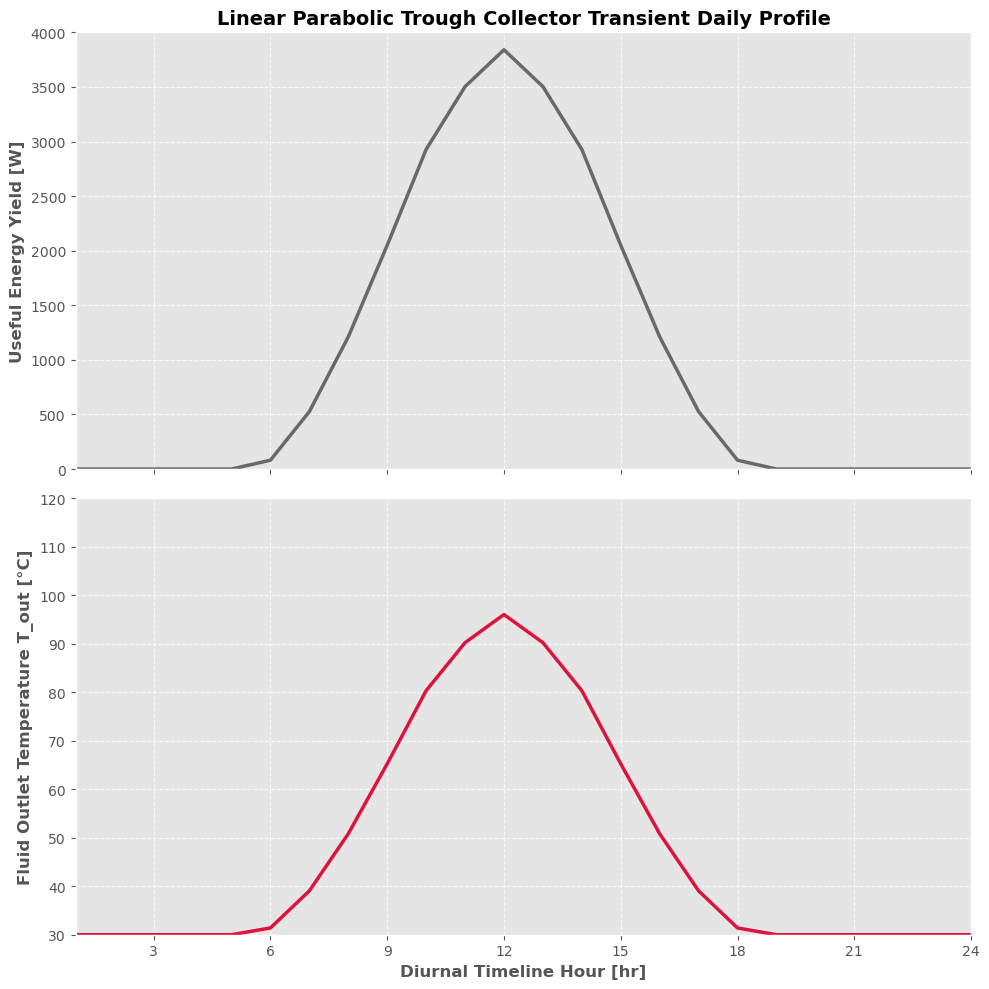

     PTC FIELD CONVERGENCE PERFORMANCE SUMMARY    
Total Daily Energy Yield       : 87961.30 kJ/day
Integrated Solar Field Area    : 10.00 m²
--------------------------------------------------
Absolute Peak Thermal Output   : 3840.30 W (at Hour 12)
Maximum Realized Fluid Temp    : 95.99 °C
Corresponding Ambient Baseline : 37.00 °C
--------------------------------------------------
Peak Field Irradiance (DNI)    : 650.0 W/m²
Minimum Incidence Tracking Dev : 15°
Approximate Core Day Efficiency: 45.26 %


In [12]:
# =============================================================================
# 5. GRAPHICS COMPILATION & CRITICAL RESULTS LOGGING REPORTER
# =============================================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

# Plot 1: Transient Thermal Energy Performance Profile
ax1.plot(df_results['Hour'], df_results['Useful Energy [W]'], color='dimgray', linewidth=2.5, label='Thermal Gain')
ax1.set_ylabel('Useful Energy Yield [W]', fontweight='bold', fontsize=12)
ax1.set_ylim(bottom=0, top=4000)
ax1.set_xlim(left=1, right=24)
ax1.set_xticks(np.arange(3, 25, 3))
ax1.set_title('Linear Parabolic Trough Collector Transient Daily Profile', fontweight='bold', fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.7)

# Plot 2: Working Fluid Temperature Propagation Curve
ax2.plot(df_results['Hour'], df_results['T_out [°C]'], color='crimson', linewidth=2.5, label='Exit State')
ax2.set_xlabel('Diurnal Timeline Hour [hr]', fontweight='bold', fontsize=12)
ax2.set_ylabel('Fluid Outlet Temperature T_out [°C]', fontweight='bold', fontsize=12)
ax2.set_ylim(bottom=30, top=120)
ax2.set_xlim(left=1, right=24)
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# ---------- Extract Key Operational Performance Results ----------
peak_row       = df_results.loc[df_results['Useful Energy [W]'].idxmax()]
total_yield_kJ = df_results['QU [kJ/hr]'].sum()
avg_efficiency = (df_results['Useful Energy [W]'].sum() / (df_results['DNI [W/m²]'].sum() * A_aperture * N_series * N_parallel + 1e-6)) * 100.0

# =============================================================================
# 6. COMPREHENSIVE REPRODUCIBILITY KEY RESULTS REPORT
# =============================================================================
print(f"==================================================")
print(f"     PTC FIELD CONVERGENCE PERFORMANCE SUMMARY    ")
print(f"==================================================")
print(f"Total Daily Energy Yield       : {total_yield_kJ:.2f} kJ/day")
print(f"Integrated Solar Field Area    : {A_aperture * N_series * N_parallel:.2f} m²")
print(f"--------------------------------------------------")
print(f"Absolute Peak Thermal Output   : {peak_row['Useful Energy [W]']:.2f} W (at Hour {int(peak_row['Hour'])})")
print(f"Maximum Realized Fluid Temp    : {peak_row['T_out [°C]']:.2f} °C")
print(f"Corresponding Ambient Baseline : {peak_row['T_amb [°C]']:.2f} °C")
print(f"--------------------------------------------------")
print(f"Peak Field Irradiance (DNI)    : {peak_row['DNI [W/m²]']:.1f} W/m²")
print(f"Minimum Incidence Tracking Dev : {df_results['Theta [°]'].iloc[5:18].min()}°")
print(f"Approximate Core Day Efficiency: {avg_efficiency:.2f} %")
print(f"==================================================")